In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    balanced_accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Try importing XGBoost and CatBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

import sys

sys.path.append('/Users/viduragunawardana/Code/DataScience/Python/dataExplore-2.0/')
from scripts import styling

In [2]:
# Target variable
TARGET = 'stroke_event'

# Features to exclude
EXCLUDE = ['patient_id', TARGET, 'Unnamed: 0']

# Numerical features
NUMERICAL_COLS = ['age', 'glucose_level', 'bmi_value', 'risk_score']

# Categorical features
CATEGORICAL_COLS = [
    'gender', 'age_group', 'has_hypertension', 'has_heart_disease',
    'marital_status', 'employment_type', 'residence', 'high_glucose',
    'bmi_category', 'smoking_habit', 'lifestyle_risk', 'cluster'
]

# Cross-validation settings
CV_FOLDS = 5
CV_STRATIFIED = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)


In [3]:
def get_models_balanced():
    """
    Returns dictionary of models WITH class balancing.
    Edit this function to add/remove/modify models.
    """
    models = {
        # --- Logistic Regression ---
        'Logistic Regression (Balanced)': LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ),
        
        # --- SVM ---
        'SVM (Balanced)': SVC(
            class_weight='balanced',
            probability=True,
            random_state=42
        ),
        
        # --- Decision Tree ---
        'Decision Tree (Balanced)': DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ),
        
        # --- Random Forest ---
        'Random Forest (Balanced)': RandomForestClassifier(
            class_weight='balanced',
            n_estimators=100,
            random_state=42
        ),
        
        # --- Gradient Boosting ---
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),
        
        # --- XGBoost ---
        # 'XGBoost (Balanced)': XGBClassifier(
        #     scale_pos_weight='balanced',
        #     n_estimators=100,
        #     use_label_encoder=False,
        #     eval_metric='logloss',
        #     random_state=42
        # ) if XGBClassifier else None,
        
        # --- CatBoost ---
        'CatBoost (Balanced)': CatBoostClassifier(
            auto_class_weights='Balanced',
            verbose=0,
            random_state=42
        ) if CatBoostClassifier else None,
    }
    
    # Remove None values (if library not installed)
    return {k: v for k, v in models.items() if v is not None}


def get_models_unbalanced():
    """
    Returns dictionary of models WITHOUT class balancing.
    Edit this function to add/remove/modify models.
    """
    models = {
        # --- Logistic Regression ---
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        
        # --- SVM ---
        'SVM (RBF)': SVC(
            probability=True,
            random_state=42
        ),
        
        # --- Decision Tree ---
        'Decision Tree': DecisionTreeClassifier(
            random_state=42
        ),
        
        # --- Random Forest ---
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        
        # --- Gradient Boosting ---
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ),
        
        # --- XGBoost ---
        # 'XGBoost': XGBClassifier(
        #     n_estimators=100,
        #     use_label_encoder=False,
        #     eval_metric='logloss',
        #     random_state=42
        # ) if XGBClassifier else None,
        
        # --- CatBoost ---
        'CatBoost': CatBoostClassifier(
            verbose=0,
            random_state=42
        ) if CatBoostClassifier else None,
    }
    
    return {k: v for k, v in models.items() if v is not None}


In [4]:
df = pd.read_csv('../data/train_with_clusters.csv')
print(f"Dataset shape: {df.shape}")

X = df.drop(columns=[col for col in EXCLUDE if col in df.columns])
y = df[TARGET]

# Encode categorical variables
le_dict = {}
for col in CATEGORICAL_COLS:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Features shape: {X_scaled.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Dataset shape: (4088, 17)
Features shape: (4088, 16)
Target distribution:
stroke_event
0    3893
1     195
Name: count, dtype: int64


In [5]:
def evaluate_model_cv(model, X, y, cv, model_name, scoring='f1'):
    """
    Evaluate a model using cross-validation.
    """
    try:
        scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        return {
            'model_name': model_name,
            'mean_score': scores.mean(),
            'std_score': scores.std(),
            'scores': scores
        }
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")
        return None


def run_cv_comparison(models, X, y, cv, scoring='f1'):
    """
    Run cross-validation for all models.
    Returns a DataFrame with results.
    """
    results = []
    
    for name, model in models.items():
        print(f"Evaluating: {name}...")
        result = evaluate_model_cv(model, X, y, cv, name, scoring)
        
        if result:
            results.append(result)
            print(f"  {name}: {result['mean_score']:.4f} (+/- {result['std_score']:.4f})")
    
    return pd.DataFrame(results)



In [6]:
balanced_models = get_models_balanced()
results_balanced = run_cv_comparison(balanced_models, X_scaled, y, CV_STRATIFIED, 'f1')


unbalanced_models = get_models_unbalanced()
results_unbalanced = run_cv_comparison(unbalanced_models, X_scaled, y, CV_STRATIFIED, 'f1')


Evaluating: Logistic Regression (Balanced)...
  Logistic Regression (Balanced): 0.2307 (+/- 0.0158)
Evaluating: SVM (Balanced)...
  SVM (Balanced): 0.2030 (+/- 0.0127)
Evaluating: Decision Tree (Balanced)...
  Decision Tree (Balanced): 0.1541 (+/- 0.0332)
Evaluating: Random Forest (Balanced)...
  Random Forest (Balanced): 0.0286 (+/- 0.0233)
Evaluating: Gradient Boosting...
  Gradient Boosting: 0.0431 (+/- 0.0246)
Evaluating: CatBoost (Balanced)...
  CatBoost (Balanced): 0.2810 (+/- 0.0501)
Evaluating: Logistic Regression...
  Logistic Regression: 0.0000 (+/- 0.0000)
Evaluating: SVM (RBF)...
  SVM (RBF): 0.0000 (+/- 0.0000)
Evaluating: Decision Tree...
  Decision Tree: 0.1631 (+/- 0.0234)
Evaluating: Random Forest...
  Random Forest: 0.0372 (+/- 0.0343)
Evaluating: Gradient Boosting...
  Gradient Boosting: 0.0431 (+/- 0.0246)
Evaluating: CatBoost...
  CatBoost: 0.0936 (+/- 0.0790)


In [7]:
results_combined = pd.concat([results_balanced, results_unbalanced], ignore_index=True)
results_combined = results_combined.sort_values('mean_score', ascending=False).reset_index(drop=True)

print(results_combined[['model_name', 'mean_score', 'std_score']].to_string(index=False))


                    model_name  mean_score  std_score
           CatBoost (Balanced)    0.280963   0.050080
Logistic Regression (Balanced)    0.230698   0.015816
                SVM (Balanced)    0.203003   0.012705
                 Decision Tree    0.163069   0.023431
      Decision Tree (Balanced)    0.154112   0.033166
                      CatBoost    0.093598   0.078961
             Gradient Boosting    0.043100   0.024639
             Gradient Boosting    0.043100   0.024639
                 Random Forest    0.037229   0.034262
      Random Forest (Balanced)    0.028582   0.023348
           Logistic Regression    0.000000   0.000000
                     SVM (RBF)    0.000000   0.000000


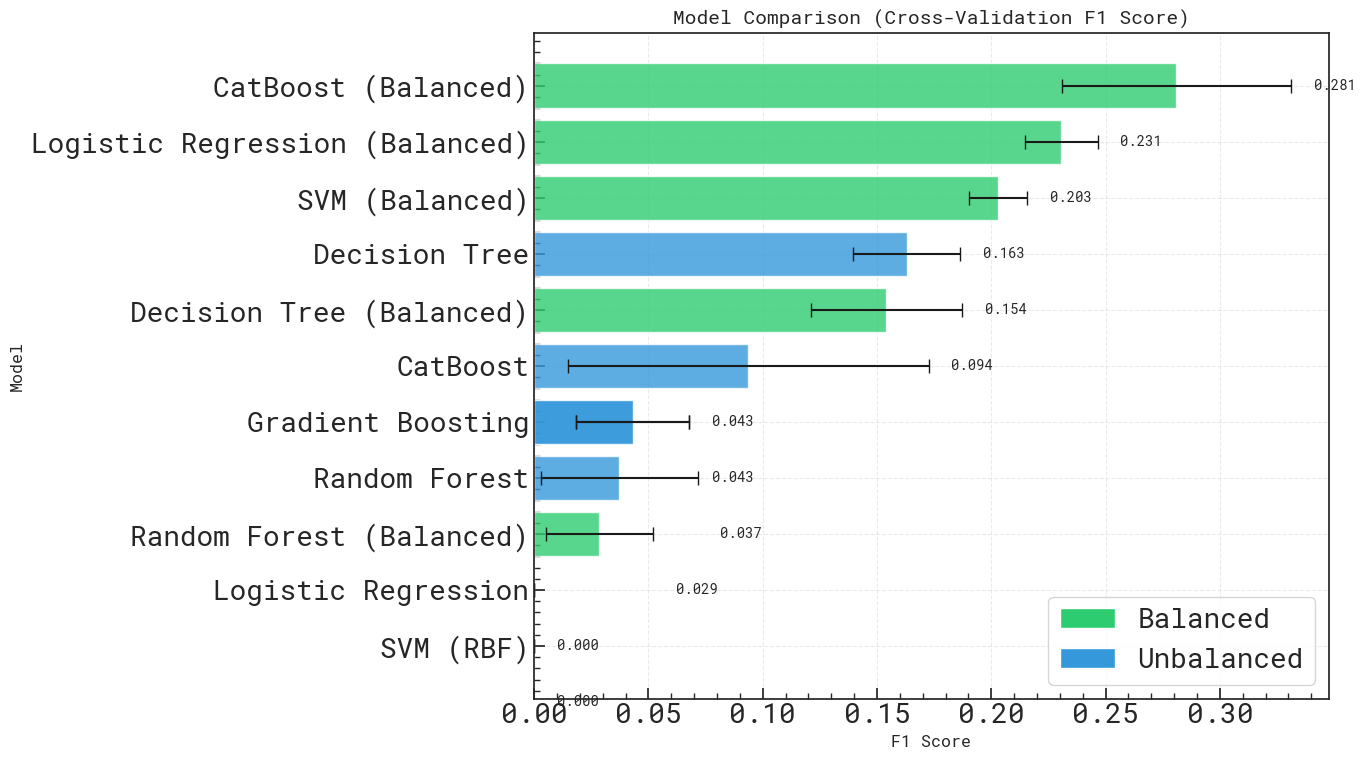

In [8]:
# Bar plot comparison
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#2ecc71' if 'Balanced' in name else '#3498db' for name in results_combined['model_name']]

bars = ax.barh(
    results_combined['model_name'],
    results_combined['mean_score'],
    xerr=results_combined['std_score'],
    color=colors,
    capsize=5,
    alpha=0.8
)

ax.set_xlabel('F1 Score', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
ax.set_title('Model Comparison (Cross-Validation F1 Score)', fontsize=14)
ax.invert_yaxis()

# Add value labels
for i, (score, std) in enumerate(zip(results_combined['mean_score'], results_combined['std_score'])):
    ax.text(score + std + 0.01, i, f'{score:.3f}', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Balanced'),
    Patch(facecolor='#3498db', label='Unbalanced')
]
ax.legend(handles=legend_elements, loc='lower right')

styling.style_ax(ax, minor_grid=False)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
def get_detailed_metrics(models, X, y, cv):
    """
    Get detailed metrics for all models.
    """
    from sklearn.model_selection import cross_val_predict
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, confusion_matrix
    )
    
    metrics_data = []
    
    for name, model in models.items():
        print(f"Detailed metrics: {name}...")
        
        # Cross-validated predictions
        y_pred = cross_val_predict(model, X, y, cv=cv)
        
        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        
        metrics_data.append({
            'Model': name,
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred),
            'Recall': recall_score(y, y_pred),
            'F1 Score': f1_score(y, y_pred),
            'ROC AUC': roc_auc_score(y, y_pred),
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        })
    
    return pd.DataFrame(metrics_data)

In [10]:

all_models = {**balanced_models, **unbalanced_models}
detailed_metrics = get_detailed_metrics(all_models, X_scaled, y, CV_STRATIFIED)

# Save results
# detailed_metrics.to_csv('model_comparison_metrics.csv', index=False)
# print("\nResults saved to 'model_comparison_metrics.csv'")

Detailed metrics: Logistic Regression (Balanced)...
Detailed metrics: SVM (Balanced)...
Detailed metrics: Decision Tree (Balanced)...
Detailed metrics: Random Forest (Balanced)...
Detailed metrics: Gradient Boosting...
Detailed metrics: CatBoost (Balanced)...
Detailed metrics: Logistic Regression...
Detailed metrics: SVM (RBF)...
Detailed metrics: Decision Tree...
Detailed metrics: Random Forest...
Detailed metrics: CatBoost...


In [11]:
detailed_metrics_styled = detailed_metrics.style.background_gradient(cmap='RdYlGn', subset=['TP', 'TN', 'Accuracy', 'Recall']) \
.background_gradient(cmap='RdYlGn_r', subset=['FP', 'FN'])

display(detailed_metrics_styled)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,TP,TN,FP,FN
0,Logistic Regression (Balanced),0.744618,0.134996,0.805128,0.231222,0.773358,157,2887,1006,38
1,SVM (Balanced),0.779354,0.122732,0.589744,0.203180,0.689298,115,3071,822,80
2,Decision Tree (Balanced),0.923434,0.164773,0.148718,0.156334,0.555479,29,3746,147,166
3,Random Forest (Balanced),0.950587,0.230769,0.015385,0.028846,0.506408,3,3883,10,192
4,Gradient Boosting,0.947652,0.172414,0.025641,0.044643,0.509738,5,3869,24,190
5,CatBoost (Balanced),0.900685,0.215633,0.410256,0.282686,0.667753,80,3602,291,115
6,Logistic Regression,0.952299,0.000000,0.000000,0.000000,0.500000,0,3893,0,195
7,SVM (RBF),0.952299,0.000000,0.000000,0.000000,0.500000,0,3893,0,195
8,Decision Tree,0.908268,0.145669,0.189744,0.164811,0.567001,37,3676,217,158
9,Random Forest,0.950342,0.250000,0.020513,0.037915,0.508715,4,3881,12,191


In [12]:
test_df = pd.read_csv('../data/test_with_clusters.csv')
# test_df.columns
# 
# Separate features and target
X_test = test_df.drop(columns=['stroke_event'])
y_test = test_df['stroke_event']

y_test.value_counts()

stroke_event
0    968
1     54
Name: count, dtype: int64

In [13]:
X_test.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk,cluster
0,F,62.0,1,0,1,working,Urban,103.69,35.2,current_smoker,senior,1,0,obese,high,0
1,F,59.0,0,0,1,government,Urban,98.52,29.8,ex_smoker,middle,0,0,overweight,medium,2
2,M,51.0,0,0,1,working,Rural,77.07,32.1,ex_smoker,middle,0,0,obese,medium,2
3,M,16.0,0,0,0,other,Urban,140.10,38.7,non_smoker,young,0,1,obese,low,1
4,F,8.0,0,0,0,other,Rural,102.50,16.3,unknown,young,0,0,underweight,low,1


In [14]:
X_test_proc = X_test.copy()

# --- 1. Label encode FIRST ---
for col in CATEGORICAL_COLS:
    if col in X_test_proc.columns:
        le = le_dict[col]
        
        X_test_proc[col] = X_test_proc[col].astype(str)
        
        # handle unseen values
        X_test_proc[col] = X_test_proc[col].apply(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
        
        X_test_proc[col] = le.transform(X_test_proc[col])

# --- 2. Match column order EXACTLY like training ---
X_test_proc = X_test_proc[X.columns]

# --- 3. Scale ALL columns at once ---
X_test_scaled = scaler.transform(X_test_proc)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [15]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix
)

In [18]:
detailed_metrics = get_detailed_metrics(all_models, X_test_scaled, y_test, CV_STRATIFIED)

Detailed metrics: Logistic Regression (Balanced)...
Detailed metrics: SVM (Balanced)...
Detailed metrics: Decision Tree (Balanced)...
Detailed metrics: Random Forest (Balanced)...
Detailed metrics: Gradient Boosting...
Detailed metrics: CatBoost (Balanced)...
Detailed metrics: Logistic Regression...
Detailed metrics: SVM (RBF)...
Detailed metrics: Decision Tree...
Detailed metrics: Random Forest...
Detailed metrics: CatBoost...


In [19]:
detailed_metrics_styled = detailed_metrics.style.background_gradient(cmap='RdYlGn', subset=['TP', 'TN', 'Accuracy', 'Recall']) \
.background_gradient(cmap='RdYlGn_r', subset=['FP', 'FN'])

display(detailed_metrics_styled)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,TP,TN,FP,FN
0,Logistic Regression (Balanced),0.693738,0.113433,0.703704,0.195373,0.698443,38,671,297,16
1,SVM (Balanced),0.769080,0.074766,0.296296,0.119403,0.545875,16,770,198,38
2,Decision Tree (Balanced),0.899217,0.070175,0.074074,0.072072,0.509661,4,915,53,50
3,Random Forest (Balanced),0.946184,0.333333,0.018519,0.035088,0.508226,1,966,2,53
4,Gradient Boosting,0.938356,0.200000,0.055556,0.086957,0.521579,3,956,12,51
5,CatBoost (Balanced),0.889432,0.116883,0.166667,0.137405,0.548209,9,900,68,45
6,Logistic Regression,0.946184,0.000000,0.000000,0.000000,0.499483,0,967,1,54
7,SVM (RBF),0.945205,0.000000,0.000000,0.000000,0.498967,0,966,2,54
8,Decision Tree,0.904110,0.145161,0.166667,0.155172,0.555957,9,915,53,45
9,Random Forest,0.947162,0.500000,0.018519,0.035714,0.508743,1,967,1,53
